In [ ]:
# imports

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from nltk.tokenize import word_tokenize
from typing import Union, Any
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb
import joblib
import nltk
import ast

In [30]:
# download data
nltk.download('punkt', quiet=True)

True

In [31]:
# Load merged data
merged_df = pd.read_parquet('../data/processed/merged_movies.parquet')

# Data cleaning
merged_df['keywords'] = merged_df['keywords'].fillna('[]')
merged_df['belongs_to_collection'] = merged_df['belongs_to_collection'].fillna(0)
merged_df['homepage_tmdb'] = merged_df['homepage_tmdb'].fillna('')
merged_df['tagline_tmdb'] = merged_df['tagline_tmdb'].fillna('')
merged_df = merged_df.dropna(subset=['release_date_tmdb', 'genres_tmdb'])


def safe_parse_json(x: Union[str, Any]) -> list[dict[str, Any]]:
    try:
        return ast.literal_eval(x) if isinstance(x, str) else []
    except:
        return []

def parse_genres(x: str) -> None:
    if pd.isna(x):
        return []
    x_str = str(x)
    if '{' in x_str:  # JSON-like
        return safe_parse_json(x_str)
    else: 
        return [{'name': g.strip()} for g in x_str.split(',') if g.strip()]  

merged_df['genres_tmdb'] = merged_df['genres_tmdb'].apply(parse_genres)

# Other JSON
merged_df['cast'] = merged_df['cast'].apply(safe_parse_json)
merged_df['crew'] = merged_df['crew'].apply(safe_parse_json)
merged_df['keywords'] = merged_df['keywords'].apply(safe_parse_json)
merged_df['production_companies_tmdb'] = merged_df['production_companies_tmdb'].apply(safe_parse_json)
merged_df['production_countries_tmdb'] = merged_df['production_countries_tmdb'].apply(safe_parse_json)
merged_df['spoken_languages_tmdb'] = merged_df['spoken_languages_tmdb'].apply(safe_parse_json)

# Basic extractions 
merged_df['num_genres'] = merged_df['genres_tmdb'].apply(len)
merged_df['primary_genre'] = merged_df['genres_tmdb'].apply(lambda x: x[0]['name'] if x else 'Unknown')
merged_df['num_cast'] = merged_df['cast'].apply(len)
merged_df['num_crew'] = merged_df['crew'].apply(len)


merged_df['release_date_tmdb'] = pd.to_datetime(merged_df['release_date_tmdb'], errors='coerce')
merged_df['release_year'] = merged_df['release_date_tmdb'].dt.year
merged_df['release_month'] = merged_df['release_date_tmdb'].dt.month
merged_df['release_season'] = merged_df['release_month'].apply(lambda m: 'Winter' if m in [12,1,2] else 'Spring' if m in [3,4,5] else 'Summer' if m in [6,7,8] else 'Fall')

# Log Revenue
merged_df['log_revenue'] = np.log1p(merged_df['revenue_tmdb'])
merged_df['avg_user_rating'] = merged_df['avg_user_rating'].clip(1, 5)

# Define Base Features
num_features = ['budget_tmdb', 'runtime_tmdb', 'popularity_tmdb', 'vote_count_tmdb', 'user_rating_count', 'num_genres', 'num_cast', 'num_crew', 'release_year']
cat_features = ['primary_genre', 'original_language_tmdb', 'release_season', 'adult_tmdb']

In [ ]:
# Helper functions

def get_cast_popularity(row):
    try:
        cast = ast.literal_eval(row['cast']) if isinstance(row['cast'], str) else row['cast']
    except:
        cast = []
    if not cast:
        return 0.0
    top_cast_len = min(len(cast), 3)
    return top_cast_len 

merged_df['cast_popularity'] = merged_df.apply(get_cast_popularity, axis=1)

# Keyword Features
def keyword_features(row):
    kw_str = str(row['keywords']).strip()
    if not kw_str or kw_str in ['', '[]', 'nan']:
        return pd.Series({'keyword_count': 0, 'pos_keyword_ratio': 0.0})
    
    try:
        kws = safe_parse_json(kw_str)
        kw_names = [kw.get('name', '').lower() for kw in kws if kw]
    except:
        kw_names = [kw.strip().lower() for kw in kw_str.split(',') if kw.strip()]
    
    count = len(kw_names)
    pos_words = ['love', 'great', 'amazing', 'hero', 'success', 'inspir', 'friend', 'family', 'heart']
    pos_count = sum(1 for kw in kw_names if any(p in kw for p in pos_words))
    ratio = pos_count / max(count, 1)
    
    return pd.Series({'keyword_count': count, 'pos_keyword_ratio': ratio})

kw_feats = merged_df.apply(keyword_features, axis=1)
merged_df = pd.concat([merged_df, kw_feats], axis=1)
merged_df = merged_df.loc[:, ~merged_df.columns.duplicated()]

# Director Score 
def get_director_score(row):
    try:
        crew = ast.literal_eval(row['crew']) if isinstance(row['crew'], str) else row['crew']
    except:
        crew = []
    directors = [c for c in crew if c.get('job') == 'Director']
    return len(directors)  # Simple: Number of directors (usually 1)

merged_df['director_score'] = merged_df.apply(get_director_score, axis=1)
merged_df = merged_df.loc[:, ~merged_df.columns.duplicated()]

In [33]:
# Overview Length
merged_df['overview_length'] = merged_df['overview_tmdb'].apply(lambda x: len(word_tokenize(str(x))) if pd.notna(x) and x else 0)
merged_df = merged_df.loc[:, ~merged_df.columns.duplicated()]

# Re-Preprocess
num_features_new = num_features + ['cast_popularity', 'keyword_count', 'pos_keyword_ratio', 'director_score', 'overview_length']

X_new = merged_df[num_features_new + cat_features]
y_revenue_new = merged_df['log_revenue']
y_rating_new = merged_df['avg_user_rating']

X_train_new, X_test_new, y_rev_train_new, y_rev_test_new = train_test_split(X_new, y_revenue_new, test_size=0.2, random_state=42)
_, _, y_rat_train_new, y_rat_test_new = train_test_split(X_new, y_rating_new, test_size=0.2, random_state=42)

preprocessor_new = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features_new),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ])

X_train_proc_new = preprocessor_new.fit_transform(X_train_new)
X_test_proc_new = preprocessor_new.transform(X_test_new)
feature_names_new = preprocessor_new.get_feature_names_out()

In [34]:
# Retrain Random Forest
rf_rev_new = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_rev_new.fit(X_train_proc_new, y_rev_train_new)

y_pred_rev_new = rf_rev_new.predict(X_test_proc_new)
rmse_rev_new = np.sqrt(mean_squared_error(y_rev_test_new, y_pred_rev_new))
mae_rev_new = mean_absolute_error(y_rev_test_new, y_pred_rev_new)
r2_rev_new = r2_score(y_rev_test_new, y_pred_rev_new)

print("Revenue RF with Engineered Features:")
print(f"RMSE: {rmse_rev_new:.4f}")
print(f"MAE: {mae_rev_new:.4f}")
print(f"R-squared: {r2_rev_new:.4f}")

import_df_rev_new = pd.DataFrame({'Feature': feature_names_new, 'Importance': rf_rev_new.feature_importances_})
print("\nTop Importances for Revenue:")
print(import_df_rev_new.sort_values('Importance', ascending=False).head(10))

Revenue RF with Engineered Features:
RMSE: 1.2241
MAE: 0.8257
R-squared: 0.6177

Top Importances for Revenue:
                   Feature  Importance
3     num__vote_count_tmdb    0.435437
0         num__budget_tmdb    0.289193
4   num__user_rating_count    0.068329
2     num__popularity_tmdb    0.038732
8        num__release_year    0.037529
1        num__runtime_tmdb    0.027752
6            num__num_cast    0.018142
13    num__overview_length    0.017426
7            num__num_crew    0.014312
5          num__num_genres    0.006637


In [35]:
# Ratings
rf_rat_new = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_rat_new.fit(X_train_proc_new, y_rat_train_new)

y_pred_rat_new = rf_rat_new.predict(X_test_proc_new)
rmse_rat_new = np.sqrt(mean_squared_error(y_rat_test_new, y_pred_rat_new))
mae_rat_new = mean_absolute_error(y_rat_test_new, y_pred_rat_new)
r2_rat_new = r2_score(y_rat_test_new, y_pred_rat_new)

print("Ratings RF with Engineered Features:")
print(f"RMSE: {rmse_rat_new:.4f}")
print(f"MAE: {mae_rat_new:.4f}")
print(f"R-squared: {r2_rat_new:.4f}")

import_df_rat_new = pd.DataFrame({'Feature': feature_names_new, 'Importance': rf_rat_new.feature_importances_})
print("\nTop Importances for Ratings:")
print(import_df_rat_new.sort_values('Importance', ascending=False).head(10))

Ratings RF with Engineered Features:
RMSE: 0.3312
MAE: 0.2537
R-squared: 0.5671

Top Importances for Ratings:
                     Feature  Importance
4     num__user_rating_count    0.217457
0           num__budget_tmdb    0.188490
1          num__runtime_tmdb    0.155602
8          num__release_year    0.096030
3       num__vote_count_tmdb    0.086436
20  cat__primary_genre_Drama    0.046500
2       num__popularity_tmdb    0.042205
7              num__num_crew    0.031020
6              num__num_cast    0.023747
13      num__overview_length    0.019759


In [36]:
#  Save and Comparison
joblib.dump(rf_rev_new, '../models/rf_revenue_engineered.pkl')
joblib.dump(rf_rat_new, '../models/rf_rating_engineered.pkl')
joblib.dump(preprocessor_new, '../models/preprocessor_engineered.pkl')


comparison_eng = pd.DataFrame({
    'Model': ['RF Baseline', 'RF Engineered'],
    'Revenue R2': [0.6104, r2_rev_new], 
    'Ratings R2': [0.5458, r2_rat_new]
})
print("Engineering Lift:")
print(comparison_eng.round(4))
comparison_eng.to_csv('../reports/engineering_lift.csv', index=False)

Engineering Lift:
           Model  Revenue R2  Ratings R2
0    RF Baseline      0.6104      0.5458
1  RF Engineered      0.6177      0.5671


In [37]:
# Base + New Features
num_features_new = ['budget_tmdb', 'runtime_tmdb', 'popularity_tmdb', 'vote_count_tmdb', 'user_rating_count', 'num_genres', 'num_cast', 'num_crew', 'release_year', 'cast_popularity', 'keyword_count', 'pos_keyword_ratio', 'director_score', 'overview_length']
cat_features = ['primary_genre', 'original_language_tmdb', 'release_season', 'adult_tmdb']

X_new = merged_df[num_features_new + cat_features]
y_revenue_new = merged_df['log_revenue']
y_rating_new = merged_df['avg_user_rating']

# Split
X_train_new, X_test_new, y_rev_train_new, y_rev_test_new = train_test_split(X_new, y_revenue_new, test_size=0.2, random_state=42)
_, _, y_rat_train_new, y_rat_test_new = train_test_split(X_new, y_rating_new, test_size=0.2, random_state=42)

# Preprocessor
preprocessor_new = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features_new),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ])

X_train_proc_new = preprocessor_new.fit_transform(X_train_new)
X_test_proc_new = preprocessor_new.transform(X_test_new)
feature_names_new = preprocessor_new.get_feature_names_out()

print(f"Engineered Data Shapes: Train {X_train_proc_new.shape}, Test {X_test_proc_new.shape}")

Engineered Data Shapes: Train (4760, 70), Test (1190, 70)


In [38]:
from sklearn.model_selection import RandomizedSearchCV

# Expanded param dist
param_dist = {
    'n_estimators': [100, 300, 500, 1000],        # More trees for deeper learning
    'learning_rate': [0.01, 0.05, 0.1, 0.2],      # Slower rates for stability
    'max_depth': [3, 4, 5, 6, 8],                 # Shallower to prevent overfit
    'min_child_weight': [1, 3, 5],                # Noise control
    'subsample': [0.6, 0.8, 1.0],                 # Row subsampling
    'colsample_bytree': [0.6, 0.8, 1.0],          # Column subsampling
    'gamma': [0, 0.1, 0.2]                        # Pruning
}

# RandomizedSearchCV for Revenue
random_rev = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
    param_distributions=param_dist,
    n_iter=50,           # 50 random samples
    scoring='r2',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_rev.fit(X_train_proc_new, y_rev_train_new)

# Evaluate
y_pred_rev_opt = random_rev.predict(X_test_proc_new)
rmse_rev_opt = np.sqrt(mean_squared_error(y_rev_test_new, y_pred_rev_opt))
mae_rev_opt = mean_absolute_error(y_rev_test_new, y_pred_rev_opt)
r2_rev_opt = r2_score(y_rev_test_new, y_pred_rev_opt)

print(f"Best Revenue Params: {random_rev.best_params_}")
print(f"Optimized Revenue RMSE: {rmse_rev_opt:.4f}, MAE: {mae_rev_opt:.4f}, R2: {r2_rev_opt:.4f}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits


Best Revenue Params: {'subsample': 0.8, 'n_estimators': 1000, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}
Optimized Revenue RMSE: 1.1842, MAE: 0.7874, R2: 0.6422


In [39]:
# RandomizedSearchCV for Ratings
random_rat = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    scoring='r2',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_rat.fit(X_train_proc_new, y_rat_train_new)

# Evaluate
y_pred_rat_opt = random_rat.predict(X_test_proc_new)
rmse_rat_opt = np.sqrt(mean_squared_error(y_rat_test_new, y_pred_rat_opt))
mae_rat_opt = mean_absolute_error(y_rat_test_new, y_pred_rat_opt)
r2_rat_opt = r2_score(y_rat_test_new, y_pred_rat_opt)

print(f"Best Ratings Params: {random_rat.best_params_}")
print(f"Optimized Ratings RMSE: {rmse_rat_opt:.4f}, MAE: {mae_rat_opt:.4f}, R2: {r2_rat_opt:.4f}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Ratings Params: {'subsample': 0.8, 'n_estimators': 1000, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}
Optimized Ratings RMSE: 0.3125, MAE: 0.2384, R2: 0.6145



Tuned XGBoost Comparison:
                   Model  Revenue R²  Revenue RMSE  Ratings R²  Ratings RMSE
0          RF Engineered      0.6177        1.2241      0.5671        0.3312
1  XGBoost Tuned Revenue      0.6422        1.1842         NaN           NaN
2  XGBoost Tuned Ratings         NaN           NaN      0.6145        0.3125


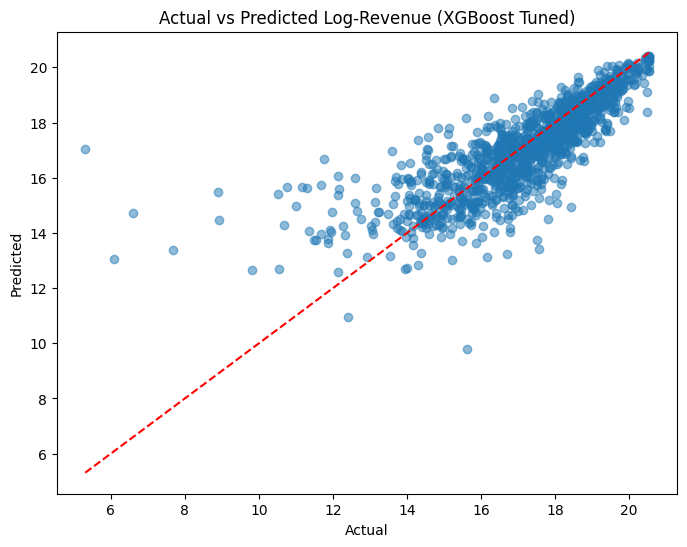

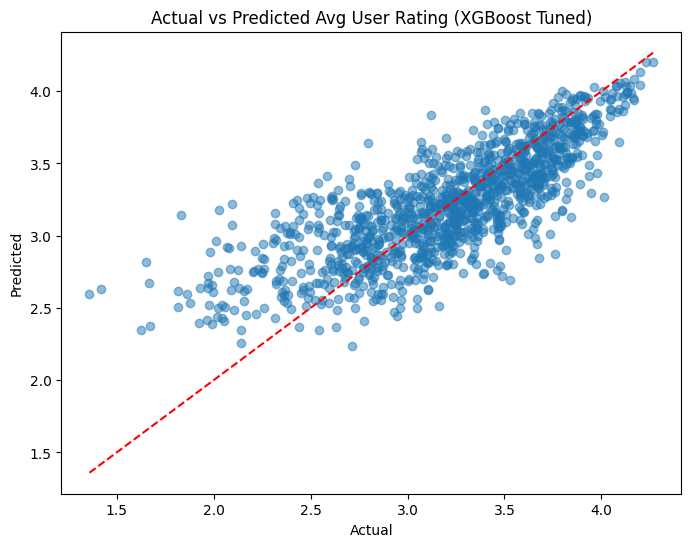

In [40]:
# Comparison Table (Tuned XGBoost vs. Previous)
comparison_tuned = pd.DataFrame({
    'Model': ['RF Engineered', 'XGBoost Tuned Revenue', 'XGBoost Tuned Ratings'],
    'Revenue R²': [0.6177, r2_rev_opt, np.nan],
    'Revenue RMSE': [1.2241, rmse_rev_opt, np.nan],
    'Ratings R²': [0.5671, np.nan, r2_rat_opt],
    'Ratings RMSE': [0.3312, np.nan, rmse_rat_opt]
})
print("\nTuned XGBoost Comparison:")
print(comparison_tuned.round(4))
comparison_tuned.to_csv('../reports/xgb_tuned_comparison.csv', index=False)

# Plot for Revenue Tuned
plt.figure(figsize=(8, 6))
plt.scatter(y_rev_test_new, y_pred_rev_opt, alpha=0.5)
plt.plot([y_rev_test_new.min(), y_rev_test_new.max()], [y_rev_test_new.min(), y_rev_test_new.max()], 'r--')
plt.title('Actual vs Predicted Log-Revenue (XGBoost Tuned)')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.savefig('../reports/figures/revenue_xgb_tuned_opt.png')
plt.show()

# Plot for Ratings Tuned
plt.figure(figsize=(8, 6))
plt.scatter(y_rat_test_new, y_pred_rat_opt, alpha=0.5)
plt.plot([y_rat_test_new.min(), y_rat_test_new.max()], [y_rat_test_new.min(), y_rat_test_new.max()], 'r--')
plt.title('Actual vs Predicted Avg User Rating (XGBoost Tuned)')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.savefig('../reports/figures/ratings_xgb_tuned_opt.png')
plt.show()

In [41]:
# Save Tuned Models
joblib.dump(random_rev, '../models/xgb_revenue_tuned_opt.pkl')
joblib.dump(random_rat, '../models/xgb_rating_tuned_opt.pkl')

['../models/xgb_rating_tuned_opt.pkl']

In [46]:
def parse_collection(x: int) -> int:
    if pd.isna(x) or x == 0:
        return 0
    try:
        col_dict = ast.literal_eval(str(x)) if isinstance(x, str) else x
        return col_dict.get('id', 0) if isinstance(col_dict, dict) else 0
    except:
        return 0

merged_df['belongs_to_collection'] = merged_df['belongs_to_collection'].apply(parse_collection)
merged_df['belongs_to_collection'] = pd.to_numeric(merged_df['belongs_to_collection'], errors='coerce').fillna(0)
merged_df.to_parquet('../data/processed/merged_engineered.parquet', index=False)

# Save preprocessor and processed splits
joblib.dump(preprocessor_new, '../models/preprocessor_engineered.pkl')

train_engineered = pd.DataFrame(X_train_proc_new, columns=feature_names_new)
train_engineered['revenue'] = y_rev_train_new
train_engineered['rating'] = y_rat_train_new
test_engineered = pd.DataFrame(X_test_proc_new, columns=feature_names_new)
test_engineered['revenue'] = y_rev_test_new
test_engineered['rating'] = y_rat_test_new

train_engineered.to_parquet('../data/processed/train_engineered.parquet', index=False)
test_engineered.to_parquet('../data/processed/test_engineered.parquet', index=False)

print("Engineered data saved successfully: merged_engineered.parquet, train/test_engineered.parquet, preprocessor_engineered.pkl")
print("belongs_to_collection sample after parse:")
print(merged_df['belongs_to_collection'].head(10).value_counts())

Engineered data saved successfully: merged_engineered.parquet, train/test_engineered.parquet, preprocessor_engineered.pkl
belongs_to_collection sample after parse:
belongs_to_collection
0    10
Name: count, dtype: int64
